# 03 — Demand Forecasting with ARIMA

A complete forecasting pipeline: load processed data, check stationarity, analyze ACF/PACF, train an ARIMA model, evaluate predictions, and generate future demand forecasts.

## 1. Load Dataset

Load the processed dataset generated by the feature engineering notebook. This already contains cleaned data with time-based features.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.utils.helpers import load_config, resolve_path

config = load_config()

processed_path = resolve_path(config["data"]["processed_dir"]) / config["data"]["processed_file"]
df = pd.read_csv(processed_path, parse_dates=["date"])

print(f"Loaded processed data: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df.head()

Loaded processed data: 898,000 rows × 22 columns
Date range: 2013-01-31 → 2017-12-31


,date,store,item,sales,year,month,quarter,day_of_week,day_of_month,week_of_year,...,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,time_index,month_sin,month_cos,store_avg_sales,item_avg_sales
0,2013-01-31,1,1,13,2013,1,1,3,31,5,...,16.0,13.0,11.000000,10.500000,2.708013,30,0.500000,0.866025,47.268379,21.981599
1,2013-02-01,1,1,11,2013,2,1,4,1,5,...,7.0,11.0,10.571429,10.500000,2.370453,31,0.866025,0.500000,47.268379,21.981599
2,2013-02-02,1,1,21,2013,2,1,5,2,5,...,18.0,14.0,11.857143,10.733333,4.634241,32,0.866025,0.500000,47.268379,21.981599
3,2013-02-03,1,1,15,2013,2,1,6,3,5,...,15.0,13.0,12.285714,10.800000,4.785892,33,0.866025,0.500000,47.268379,21.981599
4,2013-02-04,1,1,14,2013,2,1,0,4,6,...,8.0,10.0,12.714286,10.933333,4.785892,34,0.866025,0.500000,47.268379,21.981599


## 2. Time Series Preparation

Aggregate sales across all stores and items to create a single daily demand time series for forecasting.

In [2]:
daily_sales = df.groupby("date")["sales"].sum()
daily_sales = daily_sales.asfreq("D").ffill()

print(f"Time series length: {len(daily_sales)} days")
print(f"Mean daily sales  : {daily_sales.mean():,.0f}")
print(f"Std daily sales   : {daily_sales.std():,.0f}")

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily_sales.index, y=daily_sales.values,
                         mode="lines", name="Daily Total Sales",
                         line=dict(width=0.8, color="#3b82f6")))
fig.update_layout(title="Aggregated Daily Sales — Full Time Series",
                  template="plotly_dark",
                  xaxis_title="Date", yaxis_title="Total Sales")
fig.show()

Time series length: 1796 days
Mean daily sales  : 26,316
Std daily sales   : 6,293


## 3. Train-Test Split

Time-series data must be split **chronologically** — never randomly — because future values depend on past values. A random split would leak future information into training and produce misleadingly optimistic results.

We use an 80/20 split: the first 80% of days for training and the last 20% for evaluation.

In [3]:
train_size = int(len(daily_sales) * 0.8)
train = daily_sales.iloc[:train_size]
test  = daily_sales.iloc[train_size:]

print(f"Train: {len(train)} days  ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test : {len(test)} days  ({test.index[0].date()} → {test.index[-1].date()})")

fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index, y=train.values, name="Train",
                         line=dict(color="#3b82f6")))
fig.add_trace(go.Scatter(x=test.index, y=test.values, name="Test",
                         line=dict(color="#f59e0b")))
fig.update_layout(title="Train / Test Split (80 / 20)",
                  template="plotly_dark",
                  xaxis_title="Date", yaxis_title="Total Sales")
fig.show()

Train: 1436 days  (2013-01-31 → 2017-01-05)
Test : 360 days  (2017-01-06 → 2017-12-31)


## 4. Stationarity Test

ARIMA requires the input series to be **stationary** (constant mean and variance over time). The Augmented Dickey-Fuller (ADF) test checks this:

- **p-value < 0.05** → reject the null hypothesis → series is stationary
- **p-value ≥ 0.05** → fail to reject → series is non-stationary and needs differencing (the *d* parameter in ARIMA)

In [4]:
result = adfuller(train.dropna(), autolag="AIC")

print("Augmented Dickey-Fuller Test (on training set)")
print("=" * 48)
print(f"  ADF Statistic : {result[0]:.4f}")
print(f"  p-value       : {result[1]:.6f}")
print(f"  Lags Used     : {result[2]}")
print(f"  Observations  : {result[3]}")
print("\n  Critical Values:")
for key, val in result[4].items():
    print(f"    {key}: {val:.4f}")

if result[1] < 0.05:
    print("\n→ Series is stationary. ARIMA can be applied with d=0 or d=1.")
else:
    print("\n→ Series is NON-stationary. Differencing (d ≥ 1) is required.")

Augmented Dickey-Fuller Test (on training set)
  ADF Statistic : -2.7326
  p-value       : 0.068570
  Lags Used     : 21
  Observations  : 1414

  Critical Values:
    1%: -3.4350
    5%: -2.8636
    10%: -2.5679

→ Series is NON-stationary. Differencing (d ≥ 1) is required.


## 5. ACF and PACF Analysis

**Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)** plots help determine the ARIMA parameters:

- **PACF** → identifies the order of the autoregressive component **p** (the lag at which PACF cuts off)
- **ACF** → identifies the order of the moving average component **q** (the lag at which ACF cuts off)
- **d** → determined by the number of differencing steps needed to achieve stationarity

We plot both on the training set to guide our ARIMA order selection.

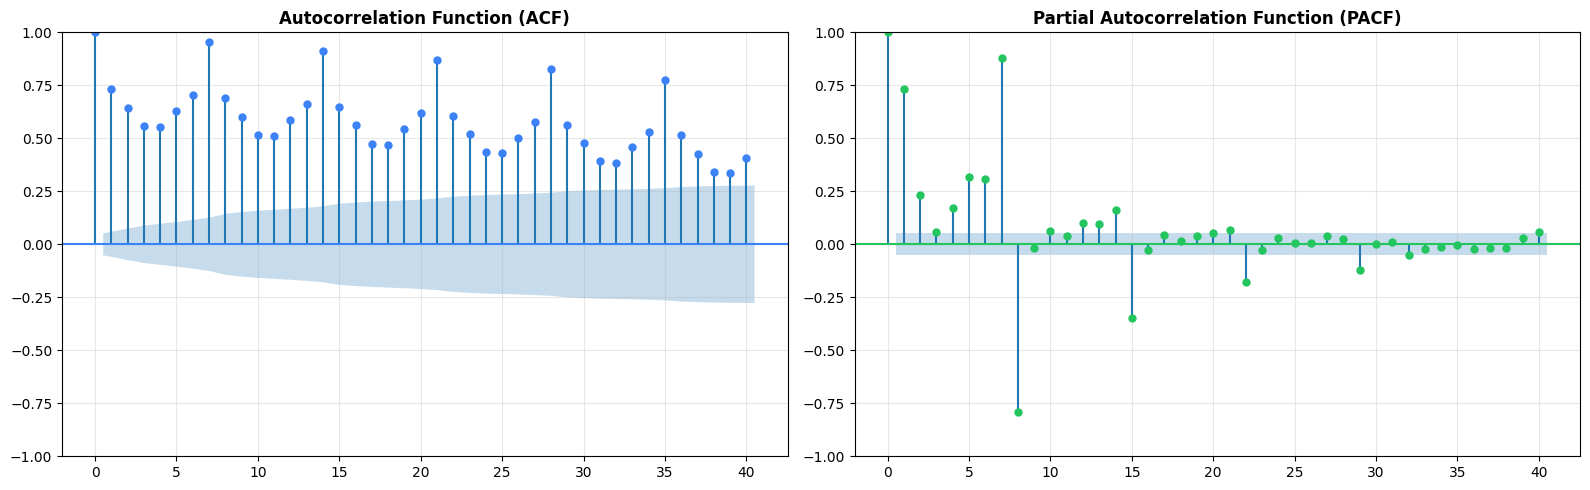

Use PACF to choose p (AR order) and ACF to choose q (MA order).
Significant spikes beyond the confidence band suggest relevant lag orders.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(train.dropna(), lags=40, ax=axes[0], color="#3b82f6")
axes[0].set_title("Autocorrelation Function (ACF)", fontsize=12, fontweight="bold")
axes[0].grid(alpha=0.3)

plot_pacf(train.dropna(), lags=40, ax=axes[1], color="#22c55e", method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF)", fontsize=12, fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Use PACF to choose p (AR order) and ACF to choose q (MA order).")
print("Significant spikes beyond the confidence band suggest relevant lag orders.")

## 6. ARIMA Model Training

ARIMA(**p**, **d**, **q**) combines three components:

| Parameter | Meaning | How to choose |
|-----------|---------|---------------|
| **p** | Auto-Regressive order — how many past values influence the current value | PACF cutoff lag |
| **d** | Differencing order — how many times to difference to achieve stationarity | ADF test result |
| **q** | Moving Average order — how many past forecast errors influence the current value | ACF cutoff lag |

We train on the **training set only** to avoid data leakage.

In [6]:
ORDER = tuple(config["forecasting"]["arima_order"])
print(f"Fitting ARIMA{ORDER} on {len(train)} training days...")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model = ARIMA(train, order=ORDER)
    fitted = model.fit()

print(f"AIC: {fitted.aic:.1f}  |  BIC: {fitted.bic:.1f}")
print(fitted.summary())

Fitting ARIMA(5, 1, 2) on 1436 training days...
AIC: 26551.2  |  BIC: 26593.3
                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1436
Model:                 ARIMA(5, 1, 2)   Log Likelihood              -13267.584
Date:                Fri, 13 Mar 2026   AIC                          26551.168
Time:                        04:06:33   BIC                          26593.320
Sample:                    01-31-2013   HQIC                         26566.906
                         - 01-05-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1112      0.011    -10.484      0.000      -0.132      -0.090
ar.L2         -0.4775      0.012    -39.996      0.00

## 7. Forecast Generation

Generate out-of-sample predictions for the test period. The model has never seen these dates during training.

In [7]:
forecast = fitted.forecast(steps=len(test))
forecast = forecast.clip(lower=0)

forecast_df = pd.DataFrame({
    "date": test.index,
    "actual_sales": test.values,
    "predicted_sales": forecast.values.round(0),
})

print(f"Generated {len(forecast_df)} predictions")
forecast_df.head(10)

Generated 360 predictions


,date,actual_sales,predicted_sales
0,2017-01-06,20994,21481.0
1,2017-01-07,22591,24426.0
2,2017-01-08,23700,21040.0
3,2017-01-09,15797,18725.0
4,2017-01-10,18608,17672.0
5,2017-01-11,18491,18351.0
6,2017-01-12,19684,19634.0
7,2017-01-13,21186,22658.0
8,2017-01-14,22434,23187.0
9,2017-01-15,23701,21384.0


## 8. Model Evaluation

Two standard metrics for regression/forecasting:

- **MAE (Mean Absolute Error)** — average magnitude of prediction errors, in the same units as sales. Easy to interpret.
- **RMSE (Root Mean Squared Error)** — penalises large errors more heavily than MAE. Lower is better for both.

In [8]:
mae  = mean_absolute_error(test.values, forecast.values)
rmse = np.sqrt(mean_squared_error(test.values, forecast.values))

print("Model Evaluation")
print("=" * 30)
print(f"  MAE  : {mae:,.2f}")
print(f"  RMSE : {rmse:,.2f}")
print(f"  Mean test sales : {test.mean():,.0f}")
print(f"  MAE as % of mean: {mae / test.mean() * 100:.1f}%")

Model Evaluation
  MAE  : 9,491.97
  RMSE : 11,056.76
  Mean test sales : 29,548
  MAE as % of mean: 32.1%


## 9. Forecast vs Actual Visualization

Overlay the training history, actual test values, and model predictions to visually assess fit quality.

In [9]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index, y=train.values,
                         name="Train", line=dict(color="#3b82f6", width=0.8)))
fig.add_trace(go.Scatter(x=test.index, y=test.values,
                         name="Actual (Test)", line=dict(color="#22c55e", width=1.5)))
fig.add_trace(go.Scatter(x=test.index, y=forecast.values,
                         name="Forecast", line=dict(color="#ef4444", width=2, dash="dash")))
fig.update_layout(
    title=f"ARIMA{ORDER} — Forecast vs Actual  (MAE={mae:,.0f}, RMSE={rmse:,.0f})",
    template="plotly_dark",
    xaxis_title="Date", yaxis_title="Total Sales",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()

## 10. Future Forecast

Re-train on the **full** dataset (train + test) to use all available information, then forecast the next 90 days into the future.

In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    full_model = ARIMA(daily_sales, order=ORDER)
    full_fitted = full_model.fit()

HORIZON = 90
future_pred = full_fitted.forecast(steps=HORIZON).clip(lower=0)
future_dates = pd.date_range(start=daily_sales.index[-1] + pd.Timedelta(days=1),
                             periods=HORIZON, freq="D")

future_df = pd.DataFrame({"date": future_dates, "forecast": future_pred.values.round(0)})

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily_sales.index, y=daily_sales.values,
                         name="Historical", line=dict(color="#3b82f6", width=0.8)))
fig.add_trace(go.Scatter(x=future_df["date"], y=future_df["forecast"],
                         name=f"{HORIZON}-Day Forecast",
                         line=dict(color="#ef4444", width=2, dash="dash")))
fig.update_layout(
    title=f"ARIMA{ORDER} — {HORIZON}-Day Future Demand Forecast",
    template="plotly_dark",
    xaxis_title="Date", yaxis_title="Total Sales",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()

## 11. Save Forecast Results

Persist the test-period comparison and future forecast to CSV so downstream tools (dashboard, reports) can consume them.

In [11]:
out_dir = resolve_path(config["outputs"]["forecasts_dir"])
out_dir.mkdir(parents=True, exist_ok=True)

forecast_df.to_csv(out_dir / "sales_forecast.csv", index=False)
print(f"Saved test comparison  → {out_dir / 'sales_forecast.csv'}")

future_df.to_csv(out_dir / "future_forecast_90d.csv", index=False)
print(f"Saved future forecast  → {out_dir / 'future_forecast_90d.csv'}")

metrics_dir = resolve_path(config["outputs"]["metrics_dir"])
metrics_dir.mkdir(parents=True, exist_ok=True)
pd.DataFrame([{"MAE": round(mae, 2), "RMSE": round(rmse, 2)}]).to_csv(
    metrics_dir / "model_metrics.csv", index=False
)
print(f"Saved model metrics    → {metrics_dir / 'model_metrics.csv'}")

Saved test comparison  → /Users/sreethanubhuvaneshgk/Downloads/desktop/home_folder/resume_project/sales-analytics-forecasting-dashboard/outputs/forecasts/sales_forecast.csv
Saved future forecast  → /Users/sreethanubhuvaneshgk/Downloads/desktop/home_folder/resume_project/sales-analytics-forecasting-dashboard/outputs/forecasts/future_forecast_90d.csv
Saved model metrics    → /Users/sreethanubhuvaneshgk/Downloads/desktop/home_folder/resume_project/sales-analytics-forecasting-dashboard/outputs/metrics/model_metrics.csv
